## AI4Climate ML tutorial - Building a machine learning model with gridded data
* Author: Stephen Haddad
* Affiliation: UK Met Office
* History: 1.0
* Last update: 2026-03-16
* © British Crown Copyright 2017-2026, Met Office. Please see LICENSE.md for license details.

## Overview of the broad topic covered

So far we have been working data in tabular format when training machine learning algorithms. We have previously encountered **gridded data**, but previously we converted this into a tabular format before using it with machine learning tools. In this notebook we will instead feed in gridded data into the training and inference of machine learning algorithms to see how working with gridded data is different to working with tabular data.





### Prerequisites 
- Same as previous  notebooks
- Have completed the training pipeline, inference and evaluation notebooks.


### Learning outcomes from completing the notebook

- Understand how to iterate through a gridded dataset for training
- Understand  how to create a convolutional neural network to work with gridded data.
- Understand how to evaluate gridded output for a regression type problem.

## Tutorial - Creating a machine learning pipe

Further Reading
* [PyTorch Docs](https://pytorch.org/)

### Environment 
This notebook uses the environment defined in this repository in the [requirements.txt](../requirements.txt) file (venv) or [requirements.yaml](../requirements.yaml).  

## Tutorial 
a balance of explanation and activity



#### Import libraries
Key libraries for this tutorial include:
- Xarray for loading the input dataset
- scikit learn for preparing the data for training
- pytorch for creating and training the neural network
- matplotlib and cartopy for visualising the results
- scores for evaluating model performance

In [1]:
import pathlib
import os
import datetime
import json
import re
import functools

In [2]:
import numpy 
import xarray

In [3]:
import matplotlib
import matplotlib.pyplot
import cartopy.crs

In [4]:
import sklearn
import sklearn.preprocessing
import sklearn.tree


In [5]:
import mlflow

In [6]:
import torch

### Specify the experiment setup

Next we specify the experiment parameters through the config file anmd specifying other elementsm like file paths.

The tutorial config from the JSON file.

In [7]:
 pathlib.Path('config.json').absolute()

PosixPath('/home/users/shaddad/prog/ai4c_hackathon/notebooks/config.json')

In [8]:
with open ('config.json','r') as tutorial_config:
    tutorial_config = json.load(tutorial_config)
tutorial_config

{'platform': 'jasmin',
 'default_dirs': {'mo_linux': '/data/users/dscop/ml_tutorial/',
  'jasmin': '/gws/ssde/j25a/mmh_storage/ai4c_data/'},
 'random_seed': 12345,
 'climate_subgroups': {'non-land': 'None',
  'Af': 'Tropical, rainforest',
  'Am': 'Tropical, monsoon',
  'Aw': 'Tropical, savannah',
  'BWh': 'Arid, desert, hot',
  'BWk': 'Arid, desert, cold',
  'BSh': 'Arid, steppe, hot',
  'BSk': 'Arid, steppe, cold',
  'Csa': 'Temperate, dry summer, hot summer',
  'Csb': 'Temperate, dry summer, warm summer',
  'Csc': 'Temperate, dry summer, cold summer',
  'Cwa': 'Temperate, dry winter, hot summer',
  'Cwb': 'Temperate, dry winter, warm summer',
  'Cwc': 'Temperate, dry winter, cold summer',
  'Cfa': 'Temperate, no dry season, hot summer',
  'Cfb': 'Temperate, no dry season, warm summer',
  'Cfc': 'Temperate, no dry season, cold summer',
  'Dsa': 'Cold, dry summer, hot summer',
  'Dsb': 'Cold, dry summer, warm summer',
  'Dsc': 'Cold, dry summer, cold summer',
  'Dsd': 'Cold, dry summer

In [9]:
def get_platform_dir(select_platform, config):
    try:
        root_path = pathlib.Path(config['default_dirs'][select_platform]) / 'weatherbench'
    except KeyError:
        root_path = pathlib.Path(os.environ['HOME']) / 'weatherbench'
    return root_path

In [10]:
current_platform = tutorial_config['platform']

In [11]:
current_platform

'jasmin'

In [12]:
root_data_dir = get_platform_dir(current_platform, tutorial_config)

print(root_data_dir.is_dir())
root_data_dir

True


PosixPath('/gws/ssde/j25a/mmh_storage/ai4c_data/weatherbench')

Define the key parameters for this experiment.

In [13]:
resolution_dict = {5.625: '5.625deg'}

In [14]:
weatherbench_dir = root_data_dir / resolution_dict[5.625]
print(weatherbench_dir.is_dir())
weatherbench_dir

True


PosixPath('/gws/ssde/j25a/mmh_storage/ai4c_data/weatherbench/5.625deg')

In [15]:
wb_arco_path = root_data_dir / 'wb_arco'
print(wb_arco_path.is_dir())
wb_arco_path

True


PosixPath('/gws/ssde/j25a/mmh_storage/ai4c_data/weatherbench/wb_arco')

### Create data objects
Next we create a Pytorch dataset class, as we did for the previous tutorial. This is a key area of difference from tabular, because we will and access and prepare the data here quite differently from what we had previously. The class still needs to itersate over the data point, but now instead of rows being data points and columns being features, we have a multi-dimensional aray. Typically in problems like this, the dimensions of the aray correspond to xarray dataset as follows:
- dimension 0 - number of data point in a mini batch
- dimension 1 - the number of variables (also called channels) in a data point.
- dimension 2 - latitude
- dimension 3 - longitude

In [16]:
class WeatherbenchDataset(torch.utils.data.Dataset):
    def __init__(self, data_dir, time_period, variables, levels, is_train=True):
        self._is_train=is_train
        self._variables = variables
        self._levels = levels

        self._ds_norm = xarray.open_zarr(data_dir)
        self._ds_norm = self._ds_norm.loc[{'time':slice(*time_period)}]
        self._ds_norm = self._ds_norm[self._variables]
        self._ds_norm = self._ds_norm.loc[dict(level=self._levels)]
        
        self._time_list = (self._ds_norm[ list(self._ds_norm.keys())[0] ]['time'].values)
        self.num_channels = len(self._ds_norm.data_vars)*len(self._ds_norm['level'])
        

    def __str__(self):
        return str(self._wb_ds)

    def __repr_html__(self):
        return self._wb_ds.__rept_html__()

    def __len__(self):
        return len(self._time_list)

    def __getitem__(self, idx):
        selected_time = self._ds_norm.time[idx].values
        select_ds = self._ds_norm.loc[{'time': selected_time}]
        if type(idx) == int:
            reshape_args = (self.num_channels, len(select_ds['lat']),len(select_ds['lon']) )
        else:
            reshape_args = (-1, self.num_channels, len(select_ds['lat']),len(select_ds['lon']) )
        select_array = numpy.stack(
            [select_ds[v1].to_numpy() for v1 in select_ds.data_vars],
            axis=1).reshape(reshape_args)
        

        select_tensor = torch.tensor(
            select_array,
            dtype=torch.float32,
        )
        return select_tensor



In [17]:
var_subset = ['temperature']
pl_subset = [500, 850, 1000]   

In [18]:
wb_train_ds = WeatherbenchDataset(wb_arco_path, 
                                  (datetime.datetime(1980,1,1,0,0), datetime.datetime(1981,11,1,0,0)),                        
                                  is_train=True,
                                  variables = var_subset,
                                  levels=pl_subset,
                                 )

/gws/nopw/j04/mohc_shared/users/shaddad/venv/ai4c_nb_gpu/lib/python3.12/site-packages/numcodecs/__init__.py:106: DeprecationWarning: crc32c usage is deprecated since numcodecs v0.16.4. It is recommended to install google_crc32c instead.
  from numcodecs.checksum32 import CRC32, Adler32, JenkinsLookup3


In [19]:
wb_val_ds = WeatherbenchDataset(wb_arco_path, 
                                  (datetime.datetime(1981,11,2,0,0), datetime.datetime(1982,1,1,0,0)), 
                                  is_train=False,
                                  variables = var_subset,
                                  levels=pl_subset,
                                 )

In [20]:
var_subset, pl_subset

(['temperature'], [500, 850, 1000])

In [21]:
wb_train_ds._ds_norm.loc[dict(level=pl_subset)]

<xarray.Dataset> Size: 395MB
Dimensions:      (time: 16081, level: 3, lat: 32, lon: 64)
Coordinates:
  * time         (time) datetime64[ns] 129kB 1980-01-01 ... 1981-11-01
  * level        (level) int32 12B 500 850 1000
  * lat          (lat) float64 256B -87.19 -81.56 -75.94 ... 75.94 81.56 87.19
  * lon          (lon) float64 512B 0.0 5.625 11.25 16.88 ... 343.1 348.8 354.4
Data variables:
    temperature  (time, level, lat, lon) float32 395MB dask.array<chunksize=(240, 3, 32, 64), meta=np.ndarray>
Attributes:
    Conventions:  CF-1.6
    history:      2020-03-03 19:31:21 GMT by grib_to_netcdf-2.16.0: /opt/ecmw...

In [22]:
len(wb_train_ds), len(wb_val_ds)

(16081, 1441)

In [23]:
wb_train_ds[:4].shape

torch.Size([4, 3, 32, 64])

In [24]:
wb_train_loader = torch.utils.data.DataLoader(wb_train_ds,
                                           batch_size=4,
                                           shuffle=True,
                                           num_workers=0,
                                          )
wb_train_loader

In [25]:
wb_val_loader = torch.utils.data.DataLoader(wb_val_ds,
                                         batch_size=4,
                                         shuffle=False,
                                         num_workers=0,
                                        )
wb_val_loader

In [26]:
count1 = 0
for X1 in wb_train_loader:
    print(X1.shape)
    count1 +=1
    if count1 > 5:
        break

torch.Size([4, 3, 32, 64])
torch.Size([4, 3, 32, 64])
torch.Size([4, 3, 32, 64])
torch.Size([4, 3, 32, 64])
torch.Size([4, 3, 32, 64])
torch.Size([4, 3, 32, 64])


### Building a convolutional autoencoder model
For this tutorial we will build an **autoencoder** model. This is an unsupervised technique where we build a model to predict the input. This may sound like a waste of compute, but the idea with autoencoders is to compress the data from a large number of parameters to a smaller bottleneck layer, usually called a **latent space**, which is a compressed representation of the data, and then reinflate the data to the original dimensions. The autoencoder learns how to encoder the data into the latent space and then recostruct the data, idealy perfectly, through a decoder layer. This architecture is the basis for many other models. We can also gain useful insights into the data through exploring the latent space in various ways.

In [27]:
# Autodetect GPU and use if possible
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
device

device(type='cuda', index=0)

In [28]:
class Era5AutoEncoder(torch.nn.Module):
    def __init__(self, num_channels, max_pool=False):
        super(Era5AutoEncoder, self).__init__()

        # we have "hard coded" a lot of the architecture hyperparameters in our model class. 
        # Usually you want want to make these arguments for the class so you can vary hyperparameters more easily.
        # Hard coding here makes it easier to follow the architecture definition in the tutorial
        self.num_channels = num_channels
        
        self._latent_array_dims = (-1,32,8,16)
        self._prelatent_size = functools.reduce(lambda a,b:a*b, self._latent_array_dims[1:])
        self._latent_size = 500
        
        self._encoder = self._get_encoder(max_pool)
        self._decoder = self._get_decoder()

    def _get_encoder(self, max_pool):
        if max_pool:
            encoder = torch.nn.Sequential(
                torch.nn.Conv2d(in_channels=self.num_channels, 
                                out_channels=16, 
                                kernel_size=3, 
                                padding=1,
                               ),
                torch.nn.ReLU(),
                torch.nn.MaxPool2d(2, stride=2),
                torch.nn.Conv2d(in_channels=16, 
                                out_channels=32, 
                                kernel_size=3, 
                                padding=1,
                               ),
                torch.nn.ReLU(),
                torch.nn.MaxPool2d(2, stride=2),
                torch.nn.Flatten(1,-1)
            )
        else:
            encoder = torch.nn.Sequential(
                torch.nn.Conv2d(in_channels=self.num_channels, 
                                out_channels=16, 
                                kernel_size=3, 
                                padding=1,
                                stride=2,
                               ),
                torch.nn.ReLU(),
                torch.nn.Conv2d(in_channels=16, 
                                out_channels=32, 
                                kernel_size=3, 
                                padding=1,
                                stride=2,
                               ),
                torch.nn.ReLU(),
                torch.nn.Flatten(1, -1),
                # torch.nn.Linear(self._prelatent_size, self._latent_size),
                # torch.nn.ReLU(),
            )
        return encoder

    def _get_decoder(self):
        """
        """
        decoder = torch.nn.Sequential(
            torch.nn.ConvTranspose2d(in_channels=32, out_channels=16, kernel_size=2,stride=2),
            torch.nn.ReLU(),
            torch.nn.ConvTranspose2d(in_channels=16, out_channels=self.num_channels, kernel_size=2,stride=2),
            # torch.nn.ReLU(),
            # torch.nn.Sigmoid(),   
        )
        return decoder
    def forward(self, x):

        # Get latent representation
        latent = self._encoder(x)

        # Reconstruct input
        reconstructed = self._decoder(latent.view(self._latent_array_dims))
        # reconstructed = self._decoder(latent)

        return reconstructed

In [29]:
# Initialize model and move to device
# ae_model = Era5AutoEncoder(wb_train_ds.num_channels, True).to(device)
ae_model = Era5AutoEncoder(wb_train_ds.num_channels, False).to(device)

We do an intiial test of a forward pass through the network with an input to check that the shape of the layers matches up. The actual values will be garbage at this point, since the weights are randomly initialised, but it is will tell us if the network architecture is programmtically valid.

In [30]:
# shape of an input
wb_val_ds[2].shape

torch.Size([3, 32, 64])

In [31]:
# check a full forward pass
ae_model.forward(wb_val_ds[2].to(device)).shape

torch.Size([3, 32, 64])

In [32]:
# pass through only encoder to see what the shape of the latent space is
ae_model._encoder(wb_val_ds[2].to(device)).shape

torch.Size([32, 8, 16])

In [33]:
sum(p.numel() for p in ae_model.parameters() if p.requires_grad)

7347

In [34]:
# Loss function and optimizer
loss_function = torch.nn.L1Loss()
# criterion = nn.KLDivLoss()
# loss_function = torch.nn.MSELoss()

optimizer = torch.optim.Adam(ae_model.parameters(), 
                             lr=5e-3)

In [35]:
num_epochs = 10

In [36]:
%%time
for epoch_num in range(num_epochs):
    print(epoch_num)
    epoch_train_loss = 0.0
    epoch_val_loss = 0.0
    
    for batch_ix, X_batch in enumerate(wb_train_loader):
        if (batch_ix % 1000) == 0:
            print(batch_ix)
        optimizer.zero_grad()
        predictions = ae_model.forward(X_batch.to(device))
        loss_batch = loss_function(predictions, X_batch.to(device))
        loss_batch.backward()
        optimizer.step()
        epoch_train_loss += loss_batch.to('cpu').item()
    epoch_train_loss /= len(wb_train_loader)

    for batch_ix_val, X_batch_val in enumerate(wb_val_loader):
        predictions_val = ae_model.forward(X_batch_val.to(device))
        loss_batch_val = loss_function(predictions_val, X_batch_val.to(device))
        epoch_val_loss += loss_batch_val.to('cpu').item()
    epoch_val_loss /= len(wb_val_loader)
    
    print(epoch_train_loss)
    print(epoch_val_loss)
        
        
        
        


0
0
1000
2000
3000
4000
0.06715946806674868
0.04725416655809595
1
0
1000
2000
3000
4000
0.044380774540380585
0.04528678202397936
2
0
1000
2000
3000
4000
0.04237956104735716
0.03926862636968039
3
0
1000
2000
3000
4000
0.04128175801015025
0.04167000632578316
4
0
1000
2000
3000
4000
0.040621013304385875
0.04069078696112553
5
0
1000
2000
3000
4000
0.04019773419917712
0.03861862131061646
6
0
1000
2000
3000
4000
0.04001034792346819
0.03884590050809271
7
0
1000
2000
3000
4000
0.03986733052597002
0.04156065736368422
8
0
1000
2000
3000
4000
0.03946191977058231
0.038260064482523795
9
0
1000
2000
3000
4000
0.0394523345217483
0.03925158890413115
CPU times: user 59min, sys: 7min 16s, total: 1h 6min 16s
Wall time: 1h 8min 11s


In [53]:
torch.save(ae_model, 'era5_ae_model_nomp.pth')

### Visualise predictions

In [54]:
wb_train_ds._ds_norm

<xarray.Dataset> Size: 395MB
Dimensions:      (time: 16081, level: 3, lat: 32, lon: 64)
Coordinates:
  * time         (time) datetime64[ns] 129kB 1980-01-01 ... 1981-11-01
  * level        (level) int32 12B 500 850 1000
  * lat          (lat) float64 256B -87.19 -81.56 -75.94 ... 75.94 81.56 87.19
  * lon          (lon) float64 512B 0.0 5.625 11.25 16.88 ... 343.1 348.8 354.4
Data variables:
    temperature  (time, level, lat, lon) float32 395MB dask.array<chunksize=(240, 3, 32, 64), meta=np.ndarray>
Attributes:
    Conventions:  CF-1.6
    history:      2020-03-03 19:31:21 GMT by grib_to_netcdf-2.16.0: /opt/ecmw...

In [84]:
sample_input = wb_train_ds._ds_norm['temperature'].sel(level=850, time='1980-03-01T13:00')

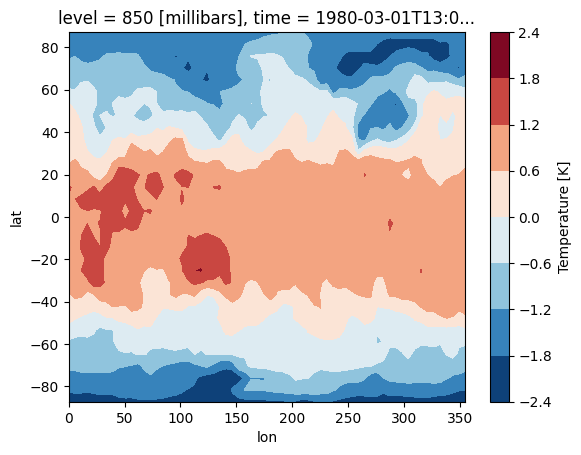

In [85]:
sample_input.plot.contourf()

create a copy of the xarray data arrray to reuse the metadata for plotting

In [57]:
float(wb_train_ds._ds_norm['temperature'].min()), float(wb_train_ds._ds_norm['temperature'].max()), float(wb_train_ds._ds_norm['temperature'].mean()), float(wb_train_ds._ds_norm['temperature'].std())

(-3.7486374378204346,
 2.4689950942993164,
 0.006472427863627672,
 1.0024229288101196)

(array([1.2819000e+04, 4.9397300e+05, 3.3895260e+06, 9.7370720e+06,
        1.3362981e+07, 1.7883984e+07, 1.7078728e+07, 3.2419848e+07,
        4.2769000e+06, 1.4583300e+05]),
 array([-3.74863744, -3.12687421, -2.50511098, -1.88334775, -1.26158452,
        -0.63982129, -0.01805806,  0.60370517,  1.2254684 ,  1.84723163,
         2.46899509]),
 <BarContainer object of 10 artists>)

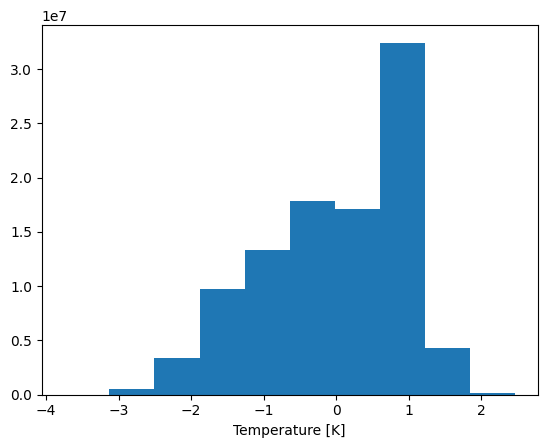

In [58]:
wb_train_ds._ds_norm['temperature'].plot.hist()

In [86]:
pred_da = xarray.DataArray(sample_input)

In [87]:
wb_val_ds[2]

tensor([[[-1.8696, -1.8851, -1.9020,  ..., -1.8191, -1.8352, -1.8524],
         [-1.4798, -1.5573, -1.6587,  ..., -1.3688, -1.3862, -1.4182],
         [-1.3435, -1.3901, -1.5876,  ..., -1.1761, -1.2460, -1.3231],
         ...,
         [-1.2405, -1.1921, -1.1892,  ..., -1.3999, -1.3937, -1.3564],
         [-1.2600, -1.2620, -1.3589,  ..., -1.2915, -1.2725, -1.2694],
         [-1.2818, -1.2737, -1.2646,  ..., -1.3361, -1.3138, -1.2942]],

        [[-2.3248, -2.3022, -2.3051,  ..., -2.2198, -2.2558, -2.2990],
         [-1.5763, -1.6395, -1.7410,  ..., -1.4329, -1.5265, -1.5451],
         [-1.1937, -1.3340, -1.5291,  ..., -1.1177, -1.1252, -1.0770],
         ...,
         [-0.9745, -0.9101, -0.9777,  ..., -1.2291, -1.0300, -0.9867],
         [-1.1882, -1.1250, -1.0895,  ..., -1.0930, -1.1781, -1.2068],
         [-1.2677, -1.2563, -1.2480,  ..., -1.3132, -1.2958, -1.2800]],

        [[-2.0442, -2.0253, -2.0266,  ..., -1.9491, -1.9789, -2.0251],
         [-1.3434, -1.4050, -1.5000,  ..., -1

In [76]:
pred_arr = ae_model.forward(wb_val_ds[2].to(device)).to('cpu').detach().numpy() 

In [77]:
pred_da.shape

(32, 64)

In [78]:
pred_arr.shape

(3, 32, 64)

In [79]:
pred_da.values = pred_arr[0,:,:]

In [80]:
pred_arr.shape

(3, 32, 64)

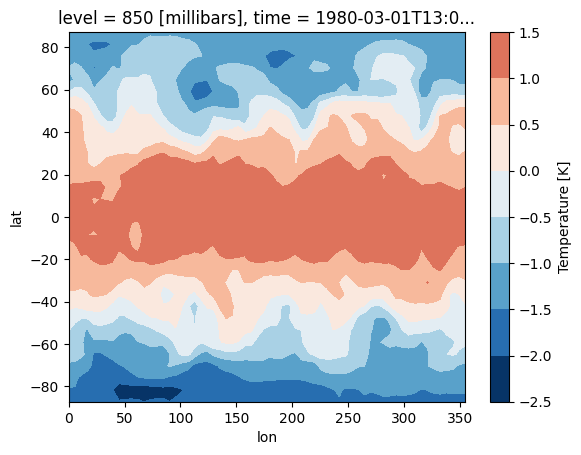

In [81]:
pred_da.plot.contourf()

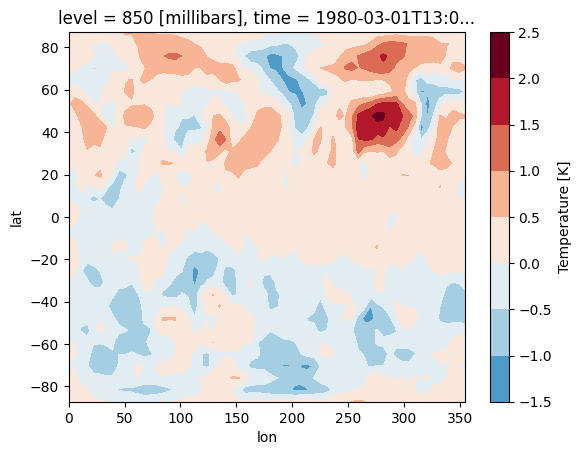

In [74]:
(pred_da - wb_train_ds._ds_norm)['temperature'].sel(level=850, time='1980-03-01T13:00').plot.contourf()

### Evaluate the results
Now we want to compare our samples to the predictor. We will start looking at RMSE, using the scores package for evaluation.

In [66]:
import scores

In [67]:
scores.continuous.rmse(
    ae_model.forward(wb_val_ds[:10].to(device)).to('cpu').detach().numpy(), 
    wb_val_ds[:10].numpy()
)

np.float32(0.06029637)

In [68]:
3+2

5

## Exercises
for students to try that do not have solutions but maybe have an answer or benchmark to facilitate understanding
